### Preamble

In [1]:
try:
    import pgmuvi
except (ImportError, ModuleNotFoundError):
    %pip install -q git+https://github.com/ICSM/pgmuvi.git
    import pgmuvi

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.2/291.2 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.8/174.8 kB 13.2 MB/s eta 0:00:00


In [3]:
# Imports and seeds for reproducibility
import gpytorch
from gpytorch.likelihoods import FixedNoiseGaussianLikelihood

seed = 0
import torch
torch.manual_seed(seed)

import numpy as np
np.random.seed(seed)

import random
random.seed(seed)

from pgmuvi.lightcurve import Lightcurve
from gpytorch.constraints import Interval
import pgmuvi.gps as gps
from pgmuvi import synthetic
from pgmuvi.preprocess import subsample_lightcurve

import matplotlib.pyplot as plt

SEED = 0
TRAINING_ITER = 1000
DTYPE = torch.float64
DEVICE = torch.device("cpu")

## Purpose of this notebook

This notebook discusses the `fit_LS()` method implemented in the `Lightcurve` class in PGMUVI and demonstrates how to use it for Lomb--Scargle period analysis of astronomical light curves.

In PGMUVI, `fit_LS()` is primarily useful as a fast diagnostic and exploratory tool. It can be used to:

- identify candidate periodicities in a light curve,
- inspect the full Lomb--Scargle periodogram,
- compare the strongest peaks in the frequency domain,
- provide initial guidance before fitting more flexible Gaussian-process models.

This notebook focuses specifically on how `fit_LS()` behaves in the current PGMUVI codebase, rather than on Lomb--Scargle analysis in the abstract. In particular, we will examine:

- how the method behaves for 1D and multiband light curves,
- what the different return modes mean,
- how significance flags are computed,
- and what practical caveats arise when interpreting the output.

A central theme of this notebook is that Lomb--Scargle in PGMUVI should usually be treated as a useful diagnostic and initialization step, not as the final word on the physically correct period in difficult or irregularly sampled cases.

## Where `fit_LS()` sits in the PGMUVI workflow

The `fit_LS()` method is part of the `Lightcurve` class and operates directly on the time-series data stored within it. Depending on how the `Lightcurve` object is constructed, this can represent:

- a single-band (1D) light curve, or  
- a multiband (2D) light curve with multiple wavelengths or bands.

The role of `fit_LS()` within the broader PGMUVI workflow is intentionally limited but important:

- It provides a **fast, non-parametric estimate** of periodic structure in the data.
- It can be used to **identify candidate frequencies** before fitting more flexible models.
- It helps **diagnose sampling limitations**, aliasing, and noise-dominated regimes.
- It is often used to **initialize or guide Gaussian-process (GP) models**, especially those with spectral-mixture or periodic structure.

### Return modes of `fit_LS()`

The behavior of `fit_LS()` depends on the keyword arguments used. There are three practically relevant modes:

1. **Full periodogram mode**
   
   - `freq_only=True`
   - Returns:
     - frequency grid
     - power evaluated at each frequency

   This is the mode to use when you want to **inspect or plot the full Lomb--Scargle periodogram**.

2. **Peak summary mode (default)**
   
   - `freq_only=False`, `return_full=False`
   - Returns:
     - peak frequencies (ordered by decreasing power)
     - boolean significance flags for each peak

   This is the mode to use when you only care about the **strongest candidate periodicities**.

3. **Combined mode**
   
   - `freq_only=False`, `return_full=True`
   - Returns:
     - peak frequencies
     - significance flags
     - full frequency grid
     - full power array

   This is the most complete mode and is useful when you want **both a summary and the full periodogram** in a single call.

### Key points to keep in mind

- The method works in **frequency space**, not period space. Any interpretation in terms of periods requires converting frequency → period.
- Peaks are returned in **descending order of power**, not by frequency or period.
- The meaning of the **significance flags differs between 1D and multiband cases**, and will be discussed later.

In the following sections, we will demonstrate these modes in practice, starting with a simple 1D example.

## Basic 1D example

We begin with a simple synthetic example for which the true period is known. The synthetic generator in `synthetic.py` produces a multiband light curve, but for this first demonstration we will extract a single band and treat it as a 1D light curve.

This lets us study the basic behavior of `fit_LS()` in the simplest possible setting before moving on to multiband use.

In this section we will:

- extract one band from the synthetic light curve,
- compute the full Lomb--Scargle periodogram,
- convert frequency to period,
- and visualize the resulting power spectrum.

For this mono-periodic example, the injected period is 150 d.

In [4]:
"""Generate a set of mono-periodic light curves using synthetic.py"""

n_per_band = (25, 40)  # number of data points per light curve limited to this range

SINGLE_DATASET_CONFIG = dict(
    period=150,
    t_span=150 * 2.3,
    n_per_band=n_per_band,
    wavelengths=[0.8, 1.2, 2.2],  # wavelengths in µm
    amplitude_law="extinction",
    seed=SEED,
)

lc2d_synth_1comp = synthetic.make_chromatic_sinusoid_2d(**SINGLE_DATASET_CONFIG)

# ------------------------------------------------------------------
# Ensure 'band' attribute exists (synthetic generator does not set it)
# ------------------------------------------------------------------
# wavelengths = lc2d_synth_1comp.xdata[:, 1]
wavelengths = np.asarray(lc2d_synth_1comp.xdata[:, 1], dtype=float)

unique_waves = np.unique(wavelengths)

# Map each wavelength to a string band label
wave_to_band = {w: str(i) for i, w in enumerate(unique_waves)}

band = np.array([f"band {wave_to_band[w]}" for w in wavelengths], dtype=object)
lc2d_synth_1comp.band = band

Note: PGMUVI does not currently provide a built-in plotting utility for Lomb--Scargle periodograms. The user is expected to retrieve the frequency grid and power using `fit_LS(freq_only=True)` and construct plots manually.

Available bands: ['band 0' 'band 1' 'band 2']
Selected band: band 0
Number of points in 1D light curve: 38


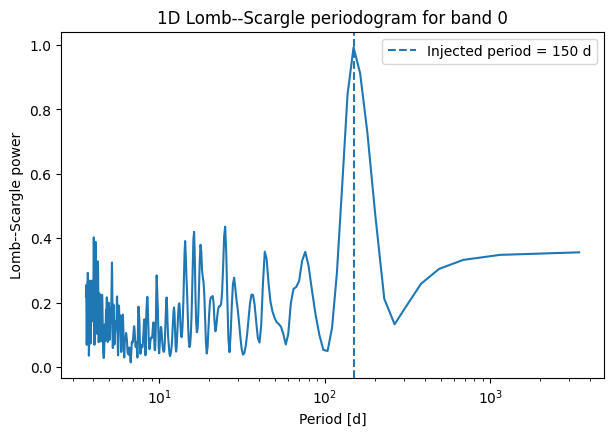

In [5]:
# Use one band from the synthetic mono-periodic 2D light curve as a 1D example
lc2d = lc2d_synth_1comp

# Inspect available band labels
bands = np.unique(lc2d.band)
print("Available bands:", bands)

# Extract the first band as a 1D light curve
band0 = bands[0]
lc1d = lc2d.select_bands([band0])

print(f"Selected band: {band0}")
print(f"Number of points in 1D light curve: {len(lc1d.xdata)}")

# Compute the full Lomb--Scargle periodogram
freq, power = lc1d.fit_LS(freq_only=True)

# Convert frequency grid to period
period = 1.0 / freq

# Sort by period for plotting
idx = np.argsort(period)
period_sorted = period[idx]
power_sorted = power[idx]

# Plot Lomb--Scargle power as a function of period
plt.figure(figsize=(7, 4.5))
plt.plot(period_sorted, power_sorted)
plt.axvline(150.0, linestyle="--", label="Injected period = 150 d")
plt.xscale("log")
plt.xlabel("Period [d]")
plt.ylabel("Lomb--Scargle power")
plt.title(f"1D Lomb--Scargle periodogram for {band0}")
plt.legend()
plt.show()

## Extracting the strongest peaks

The previous example used `freq_only=True`, which returns the full frequency grid and the corresponding Lomb--Scargle power. That is useful for plotting the periodogram.

Often, however, we only want a compact summary of the strongest candidate periodicities. In that case, we use the default summary mode:

- `freq_only=False`
- `return_full=False`

In this mode, `fit_LS()` returns:

- the frequencies of the strongest detected peaks, ordered by decreasing power,
- and a boolean mask indicating which of those peaks are considered significant.

Since `fit_LS()` works in frequency space, we will explicitly convert the returned peak frequencies to periods before interpreting them.

In [6]:
# Extract the strongest Lomb--Scargle peaks from the same 1D light curve
peak_freqs, signif_mask = lc1d.fit_LS(
    freq_only=False,
    num_peaks=5,
    return_full=False,
)

peak_periods = 1.0 / peak_freqs

print("Strongest detected peaks:")
for i, (f, p, is_sig) in enumerate(zip(peak_freqs, peak_periods, signif_mask), start=1):
    print(
        f"Peak {i}: "
        f"frequency = {float(f):.6f}, "
        f"period = {float(p):.3f} d, "
        f"significant = {bool(is_sig)}"
    )

print("\nInjected period = 150.0 d")

Strongest detected peaks:
Peak 1: frequency = 0.006704, period = 149.171 d, significant = True
Peak 2: frequency = 0.039931, period = 25.043 d, significant = False
Peak 3: frequency = 0.061499, period = 16.260 d, significant = False
Peak 4: frequency = 0.248038, period = 4.032 d, significant = False
Peak 5: frequency = 0.069660, period = 14.355 d, significant = False

Injected period = 150.0 d


## Returning both the peak summary and the full periodogram

In some situations, we want both views of the Lomb--Scargle result at once:

- a compact summary of the strongest peaks, and
- the full frequency grid and periodogram power for plotting or further analysis.

For that, `fit_LS()` provides the option:

- `freq_only=False`
- `return_full=True`

In this mode, the method returns four objects:

1. the frequencies of the strongest peaks,
2. a boolean mask indicating which of those peaks are significant,
3. the full frequency grid,
4. and the full Lomb--Scargle power evaluated on that grid.

This can be convenient because it avoids having to call `fit_LS()` twice when both the peak summary and the full periodogram are needed.

In [7]:
# Return both the peak summary and the full periodogram
peak_freqs_full, signif_mask_full, freq_full, power_full = lc1d.fit_LS(
    freq_only=False,
    num_peaks=5,
    return_full=True,
)

peak_periods_full = 1.0 / peak_freqs_full
period_full = 1.0 / freq_full

print("Peak summary from combined return mode:")
for i, (f, p, is_sig) in enumerate(
    zip(peak_freqs_full, peak_periods_full, signif_mask_full),
    start=1,
):
    print(
        f"Peak {i}: "
        f"frequency = {float(f):.6f}, "
        f"period = {float(p):.3f} d, "
        f"significant = {bool(is_sig)}"
    )

print(f"\nLength of full frequency grid: {len(freq_full)}")
print(f"Length of full power array:    {len(power_full)}")

Peak summary from combined return mode:
Peak 1: frequency = 0.006704, period = 149.171 d, significant = True
Peak 2: frequency = 0.039931, period = 25.043 d, significant = False
Peak 3: frequency = 0.061499, period = 16.260 d, significant = False
Peak 4: frequency = 0.248038, period = 4.032 d, significant = False
Peak 5: frequency = 0.069660, period = 14.355 d, significant = False

Length of full frequency grid: 475
Length of full power array:    475


## How to interpret the outputs

Before moving on to more complex cases, it is important to be precise about what `fit_LS()` actually returns and how those outputs should be interpreted.

### Frequencies vs periods

All outputs from `fit_LS()` are in **frequency space**. This means:

- the returned peak values are frequencies,
- the period must always be computed explicitly as:

  period = 1 / frequency

Any scientific interpretation (e.g., comparing with expected pulsation timescales) should be done in period space, not frequency space.

### Ordering of peaks

The returned peaks are:

- ordered by **decreasing Lomb--Scargle power**,
- not by frequency or period.

This is important because:

- the first peak is simply the strongest in the periodogram,
- it is not guaranteed to correspond to the physically correct period.

### Meaning of the significance mask

The boolean array returned alongside the peak frequencies indicates whether each peak passes an internal significance criterion.

However:

- this is **not a direct p-value**,  
- it is the result of a thresholding procedure applied to the Lomb--Scargle false-alarm probabilities.

In particular:

- significance is determined differently for single-band and multiband cases,
- and should be treated as a **heuristic filter**, not a definitive statistical decision.

### Practical takeaway

- Always convert frequencies to periods before interpretation.
- Do not assume that the top-ranked peak is physically correct.
- Treat the significance mask as a guide, not a guarantee.

In the following sections, we will explore how these issues become more pronounced in multiband data and in realistic sampling conditions.

## Multiband Lomb--Scargle in PGMUVI

So far, we have treated a single band extracted from a multiband light curve. However, `fit_LS()` can operate directly on the full multiband dataset.

In this case:

- the input light curve contains multiple bands (stored via the `band` attribute),
- the method uses a multiband Lomb--Scargle implementation internally,
- and all bands are analyzed simultaneously.

This is not equivalent to running Lomb--Scargle independently on each band. Instead, the method attempts to infer a shared periodic signal across bands, while allowing for differences in sampling and amplitude.

This can be advantageous when:

- individual bands are sparsely sampled,
- or when the signal is present across multiple wavelengths but is weak in any one band.

In this section, we will:

- run `fit_LS()` directly on the full multiband light curve,
- inspect the resulting periodogram,
- and compare it with the single-band result from earlier.

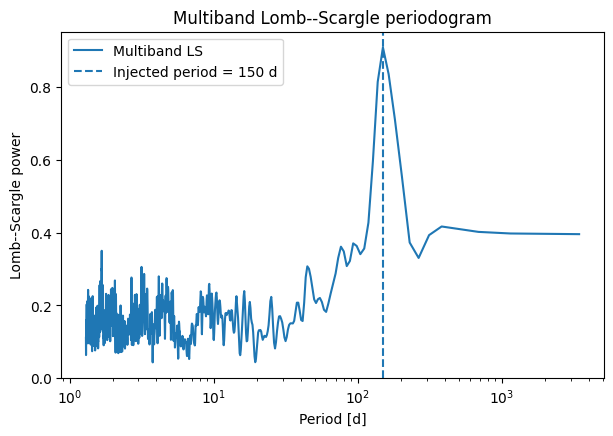

In [8]:
# Run Lomb–Scargle directly on the full multiband light curve
lc2d = lc2d_synth_1comp

# Compute full multiband periodogram
freq_mb, power_mb = lc2d.fit_LS(freq_only=True)

# Convert to period
period_mb = 1.0 / freq_mb

# Sort for plotting
idx = np.argsort(period_mb)
period_mb_sorted = period_mb[idx]
power_mb_sorted = power_mb[idx]

# Plot multiband periodogram
plt.figure(figsize=(7, 4.5))
plt.plot(period_mb_sorted, power_mb_sorted, label="Multiband LS")
plt.axvline(150.0, linestyle="--", label="Injected period = 150 d")
plt.xscale("log")
plt.xlabel("Period [d]")
plt.ylabel("Lomb--Scargle power")
plt.title("Multiband Lomb--Scargle periodogram")
plt.legend()
plt.show()

## How multiband Lomb--Scargle differs from single-band analysis

At first glance, applying `fit_LS()` to a multiband light curve may seem like a straightforward extension of the single-band case. In practice, there are several important differences that affect both the results and their interpretation.

### Joint analysis across bands

In the multiband case:

- all bands are analyzed simultaneously,
- the method attempts to identify a **shared periodic signal**,
- rather than treating each band independently.

This means that:

- information from well-sampled bands can help constrain poorly sampled ones,
- but inconsistencies between bands can also broaden or shift the detected peaks.

### Sensitivity to heterogeneous sampling

A key issue in multiband datasets is that different bands often have:

- different numbers of observations,
- different time coverage,
- and different noise levels.

As a result:

- the effective sensitivity of the periodogram can be dominated by one or two bands,
- and the resulting peak structure may not reflect all bands equally.

This is particularly important in PGMUVI, where multiband light curves are often constructed from heterogeneous surveys.

### Interpretation of peaks

Compared to the 1D case:

- peaks in the multiband periodogram may be broader,
- multiple nearby peaks may appear due to competing constraints across bands,
- and the highest peak is not necessarily the most physically meaningful solution.

### Significance in the multiband case

The significance flags returned by `fit_LS()`:

- are computed differently in the multiband case,
- and should be interpreted with additional caution.

In particular:

- they do not fully capture inter-band inconsistencies,
- and should not be treated as definitive evidence for or against a periodic signal.

### Practical takeaway

When working with multiband data:

- always compare multiband results with single-band results,
- inspect multiple peaks, not just the top one,
- and consider the sampling properties of each band.

In the next section, we will examine one specific option that can strongly affect multiband results: `use_best_band_init`.

## Effect of `use_best_band_init` on the frequency grid

One subtle but important option in `fit_LS()` is:

    use_best_band_init=True

This affects how the frequency grid is constructed in the multiband case.

### Why this matters

The Lomb--Scargle periodogram is evaluated on a grid of frequencies. In multiband data, this grid must be chosen based on the sampling properties of the data.

By default:

- the frequency grid is determined using the combined dataset,
- which may include sparsely sampled bands.

However, if one band is significantly better sampled than the others, this default choice can:

- reduce the effective resolution of the grid,
- or bias the search toward the characteristics of the combined sampling rather than the best band.

### What `use_best_band_init=True` does

When this option is enabled:

- the frequency grid is derived from the **best-sampled band**,
- and then applied to the full multiband dataset.

This can improve:

- frequency resolution,
- peak sharpness,
- and recovery of the true underlying period.

### When to use it

This option is particularly useful when:

- one band clearly dominates in terms of sampling quality,
- or when multiband results appear smeared or poorly resolved.

In the example below, we compare the multiband periodogram with and without this option.

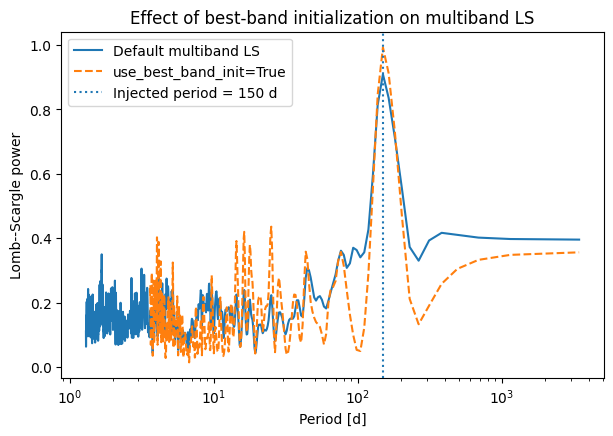

In [9]:
# Compare multiband LS with and without use_best_band_init

lc2d = lc2d_synth_1comp

# Default multiband LS
freq_default, power_default = lc2d.fit_LS(freq_only=True)

# Best-band-initialized multiband LS
freq_best, power_best = lc2d.fit_LS(
    freq_only=True,
    use_best_band_init=True,
)

# Convert to periods
period_default = 1.0 / freq_default
period_best = 1.0 / freq_best

# Sort for plotting
idx_def = np.argsort(period_default)
idx_best = np.argsort(period_best)

period_default = period_default[idx_def]
power_default = power_default[idx_def]

period_best = period_best[idx_best]
power_best = power_best[idx_best]

# Plot comparison
plt.figure(figsize=(7, 4.5))
plt.plot(period_default, power_default, label="Default multiband LS")
plt.plot(period_best, power_best, linestyle="--", label="use_best_band_init=True")

plt.axvline(150.0, linestyle=":", label="Injected period = 150 d")

plt.xscale("log")
plt.xlabel("Period [d]")
plt.ylabel("Lomb--Scargle power")
plt.title("Effect of best-band initialization on multiband LS")
plt.legend()
plt.show()

## Quantitative comparison of periodogram peaks

The visual comparison above suggests that `use_best_band_init=True` produces a sharper and higher peak at the true period.

To make this precise, we can compare:

- **peak height**: the maximum Lomb--Scargle power.  
  This measures how strong the detected signal is relative to the noise background.

- **peak prominence**: how distinct the peak is relative to its surroundings.  
  A peak with high prominence stands clearly above neighboring structure, while a low-prominence peak may be part of a broader plateau or contaminated by nearby competing frequencies. This is especially important in irregularly sampled data where aliases and side lobes can appear.

- **area fraction**: how concentrated the total power is around the peak.  
  This measures the fraction of the total periodogram power contained within a window around the peak. A high area fraction indicates a well-localized, coherent signal, whereas a low value suggests that the power is spread over a wide range of frequencies, which can indicate poor constraint, multiple competing solutions, or long-timescale structure.

These metrics help quantify whether a detected period is:

- sharply localized (high coherence),
- or broad and diffuse (low coherence / possible artifacts).

In the following cell, we compute these quantities for both configurations.

In [10]:
# Quantitative comparison of peak properties

from scipy.signal import find_peaks, peak_prominences
from scipy.integrate import trapezoid as trapz

def compute_peak_metrics(period, power):
    # Identify peaks
    peaks, _ = find_peaks(power)

    if len(peaks) == 0:
        return None

    # Take the highest peak
    peak_idx = peaks[np.argmax(power[peaks])]

    peak_height = power[peak_idx]

    # Prominence
    prominences = peak_prominences(power, peaks)[0]
    peak_prominence = prominences[np.argmax(power[peaks])]

    # Area fraction: integrate power in a window around the peak
    # Define a window of ±10% in period space
    p0 = period[peak_idx]
    mask = (period > 0.9 * p0) & (period < 1.1 * p0)

    area_peak = trapz(power[mask], period[mask])
    area_total = trapz(power, period)

    area_fraction = area_peak / area_total if area_total > 0 else np.nan

    return {
        "peak_period": p0,
        "peak_height": peak_height,
        "peak_prominence": peak_prominence,
        "area_fraction": area_fraction,
    }

# Compute metrics
metrics_default = compute_peak_metrics(period_default, power_default)
metrics_best = compute_peak_metrics(period_best, power_best)

print("Default multiband LS:")
for k, v in metrics_default.items():
    print(f"  {k}: {float(v):.6f}")

print("\nuse_best_band_init=True:")
for k, v in metrics_best.items():
    print(f"  {k}: {float(v):.6f}")

Default multiband LS:
  peak_period: 149.170715
  peak_height: 0.909449
  peak_prominence: 0.579050
  area_fraction: 0.016485

use_best_band_init=True:
  peak_period: 149.170715
  peak_height: 0.992789
  peak_prominence: 0.859738
  area_fraction: 0.020845


## Interpreting the quantitative comparison

These results support the visual impression from the previous figure.

Both configurations recover essentially the same peak period, about 149.17 d, which is close to the injected 150 d period. The main difference is therefore not the location of the peak, but how clearly and how strongly that peak is represented in the periodogram.

In this example, `use_best_band_init=True` gives:

- a higher **peak height**,
- a higher **peak prominence**,
- and a higher **area fraction**.

Taken together, this indicates that the signal is not merely detected at the correct period, but is also more sharply localized and more distinct from surrounding structure when the frequency grid is initialized from the best-sampled band. In other words, the periodogram is cleaner and less smeared in the neighborhood of the true solution.

However, this does **not** mean that `use_best_band_init=True` should always be expected to perform better.

The reason is that this option assumes that the best-sampled band provides the most useful frequency-grid initialization for the full multiband problem. That will often be a good assumption, but not always. Situations that can deviate from this expectation include:

- cases where the best-sampled band is also the noisiest band,
- cases where that band contains systematics or artifacts not present in the other bands,
- cases where another band has fewer points but a much cleaner periodic signal,
- or cases where all bands are already sampled similarly well, so that using the best band provides little practical advantage.

In such situations, `use_best_band_init=True` can produce little improvement, or in some cases even emphasize a suboptimal part of frequency space.

The practical lesson is that `use_best_band_init=True` should be treated as a useful option to test, not as a universally superior setting. In well-behaved heterogeneous datasets such as the present synthetic example, it can sharpen the recovery of the true period. But its effect should always be judged from the resulting periodogram and, when possible, from quantitative diagnostics such as those computed above.

## Two-component multiband example

So far, we have worked with a mono-periodic light curve. In realistic applications, light curves often contain multiple periodic components.

In this section, we construct a synthetic multiband light curve with:

- two periodic components,
- different amplitudes,
- and a phase offset between them.

We then modify this setup in an important way: after generating the baseline multiband dataset, we add one extra band with substantially denser sampling than the others.

This is done deliberately so that `use_best_band_init=True` has a clearly distinct, most-observed band from which to construct the initial frequency grid. In the earlier version of this example, all bands had roughly similar sampling, which made it difficult to isolate the effect of this option.

This provides a more informative test of `fit_LS()`, since:

- multiple peaks should appear in the periodogram,
- the strongest peak may not correspond to the dominant physical component in all bands,
- peak structure can become more complex due to interference between components,
- and the effect of `use_best_band_init=True` can be tested in a setting with genuinely heterogeneous sampling.

We will:

- generate the baseline two-component synthetic dataset,
- generate one additional high-sampling band,
- merge that band into the multiband light curve,
- and then inspect how the multiple periods are recovered with and without `use_best_band_init=True`.

In [11]:
"""Generate a set of light curves with two period components and a phase lag"""

n_per_band = (25, 40)  # baseline sampling

MULTI_DATASET_CONFIG = dict(
    components=[
        {"period": 150.0, "amplitude_fraction": 1.0, "phase": 0.0},
        {"period": 66.0, "amplitude_fraction": 0.3, "phase": np.pi / 2 * 0.85},
    ],
    t_span=150 * 2.3,
    n_per_band=n_per_band,
    wavelengths=[0.8, 1.2, 2.2],
    amplitude_law="extinction",
    noise_level=0.05,
    seed=SEED,
)

lc2d_synth_2comp = synthetic.make_multi_sinusoid_chromatic_2d(**MULTI_DATASET_CONFIG)

# ------------------------------------------------------------------
# Ensure 'band' attribute exists
# ------------------------------------------------------------------
wavelengths = np.asarray(lc2d_synth_2comp.xdata[:, 1], dtype=float)

unique_waves = np.unique(wavelengths)
wave_to_band = {w: str(i) for i, w in enumerate(unique_waves)}

band = np.array([f"band {wave_to_band[w]}" for w in wavelengths], dtype=object)

lc2d_synth_2comp.band = band

In [12]:
"""Generate one additional band with significantly denser sampling"""

n_per_band_hs = (100, 250)

HS_DATASET_CONFIG = dict(
    components=[
        {"period": 150.0, "amplitude_fraction": 1.0, "phase": 0.0},
        {"period": 66.0, "amplitude_fraction": 0.3, "phase": np.pi / 2 * 0.85},
    ],
    t_span=150 * 2.3,
    n_per_band=n_per_band_hs,
    wavelengths=[1.02],
    amplitude_law="extinction",
    noise_level=0.05,
    seed=SEED + 1,
)

lc_HS = synthetic.make_multi_sinusoid_chromatic_2d(**HS_DATASET_CONFIG)

# ------------------------------------------------------------------
# Assign band label explicitly
# ------------------------------------------------------------------
wavelengths = np.asarray(lc_HS.xdata[:, 1], dtype=float)

band = np.repeat("band 3", len(wavelengths))

lc_HS.band = band

In [13]:
# Merge the high-sampling band into the multiband dataset

lc2d_synth_2comp_hs = lc2d_synth_2comp.merge(lc_HS)

# Sanity check: count points per band
bands = np.unique(lc2d_synth_2comp_hs.band)
band_counts = {band: int(np.sum(lc2d_synth_2comp_hs.band == band)) for band in bands}

print("Band counts after merge:")
for k, v in band_counts.items():
    print(f"  {k}: {v}")

Band counts after merge:
  band 0: 38
  band 1: 35
  band 2: 33
  band 3: 171


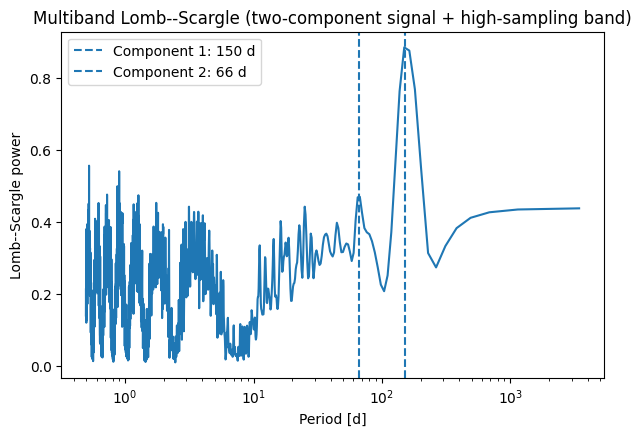

In [14]:
# Run multiband Lomb–Scargle on the two-component dataset
# after adding one extra high-sampling band

freq_2c, power_2c = lc2d_synth_2comp_hs.fit_LS(freq_only=True)

period_2c = 1.0 / freq_2c

# Sort for plotting
idx = np.argsort(period_2c)
period_2c = period_2c[idx]
power_2c = power_2c[idx]

# Plot
plt.figure(figsize=(7, 4.5))
plt.plot(period_2c, power_2c)

plt.axvline(150.0, linestyle="--", label="Component 1: 150 d")
plt.axvline(66.0, linestyle="--", label="Component 2: 66 d")

plt.xscale("log")
plt.xlabel("Period [d]")
plt.ylabel("Lomb--Scargle power")
plt.title("Multiband Lomb--Scargle (two-component signal + high-sampling band)")
plt.legend()
plt.show()

## Comparing the two-component case with and without `use_best_band_init`

We now compare the multiband Lomb--Scargle periodogram for the merged dataset:

- once using the default initialization, and
- once using `use_best_band_init=True`.

This comparison is now more informative than before, because the dataset has been constructed to include one clearly distinct, high-sampling band.

In the current implementation, `use_best_band_init=True` selects the band with the largest number of observations and uses that band to define the initial frequency grid. Since we explicitly added such a band, this example provides a cleaner test of how that choice affects the recovery of the periodic components.

For a two-component signal, this comparison is useful because it can affect:

- how sharply the dominant component is localized,
- how clearly the weaker component is separated from nearby structure,
- and how much additional fine-scale structure appears elsewhere in the periodogram.

In the next cell, we compare the two periodograms directly.

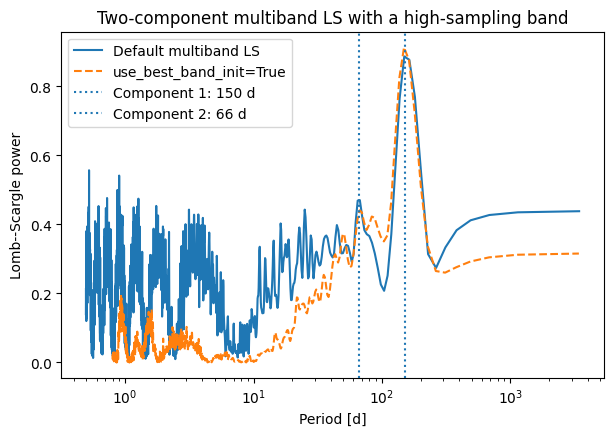

In [15]:
# Compare the two-component multiband LS periodogram
# with and without use_best_band_init

lc2d = lc2d_synth_2comp_hs

# Default multiband LS
freq_2c_default, power_2c_default = lc2d.fit_LS(freq_only=True)

# Best-band-initialized multiband LS
freq_2c_best, power_2c_best = lc2d.fit_LS(
    freq_only=True,
    use_best_band_init=True,
)

# Convert to periods
period_2c_default = 1.0 / freq_2c_default
period_2c_best = 1.0 / freq_2c_best

# Sort for plotting
idx_def = np.argsort(period_2c_default)
idx_best = np.argsort(period_2c_best)

period_2c_default = period_2c_default[idx_def]
power_2c_default = power_2c_default[idx_def]

period_2c_best = period_2c_best[idx_best]
power_2c_best = power_2c_best[idx_best]

# Plot comparison
plt.figure(figsize=(7, 4.5))
plt.plot(period_2c_default, power_2c_default, label="Default multiband LS")
plt.plot(period_2c_best, power_2c_best, linestyle="--", label="use_best_band_init=True")

plt.axvline(150.0, linestyle=":", label="Component 1: 150 d")
plt.axvline(66.0, linestyle=":", label="Component 2: 66 d")

plt.xscale("log")
plt.xlabel("Period [d]")
plt.ylabel("Lomb--Scargle power")
plt.title("Two-component multiband LS with a high-sampling band")
plt.legend()
plt.show()

## Interpreting the two-component comparison with a high-sampling band

In this modified example, we have explicitly introduced a band with substantially denser sampling than the others. As a result, `use_best_band_init=True` now selects a band that genuinely provides finer temporal resolution than the rest of the dataset.

This produces a noticeably different behavior compared to the earlier case with nearly uniform sampling.

### Dominant component (~150 d)

The dominant peak near 150 d is:

- slightly higher,
- and more sharply localized

when `use_best_band_init=True` is used.

This is consistent with the expectation that a better-sampled band can provide a more refined frequency grid, allowing the periodogram to localize the strongest signal more precisely.

### Secondary component (~66 d)

The behavior of the secondary component is less encouraging.

- The peak near 66 d is present in both cases,
- but it is not clearly better isolated when `use_best_band_init=True` is used.

In particular:

- the dip on the lower-period side is not substantially improved,
- and on the higher-period side, competing structure becomes more prominent, especially around periods near 100 d.

This means that, in this example, the improved sampling of the selected band helps the dominant component much more than the weaker one. For the secondary signal, the local periodogram structure remains ambiguous and may even become slightly harder to interpret because nearby competing power is enhanced.

### Short-period region

A key difference appears at short periods:

- the default multiband periodogram shows substantial power and structure,
- while the `use_best_band_init=True` curve is strongly suppressed in this region.

This suggests that the frequency grid inherited from the high-sampling band reduces spurious short-period structure that is present when the combined multiband sampling is used directly.

### Overall interpretation

In this case, `use_best_band_init=True` provides a selective improvement:

- the dominant peak is better localized,
- the short-period region is cleaner,
- but the weaker component near 66 d is not clearly improved and remains entangled with nearby competing structure.

This is an important practical lesson. Even when one band is substantially better sampled than the others, `use_best_band_init=True` does not guarantee uniformly better recovery of all periodic components. It can sharpen the strongest signal while leaving weaker components ambiguous, or even shifting the balance among nearby competing peaks.

This example therefore illustrates both the utility and the limitations of the option in a realistic multicomponent setting.

## Comparing sampling metrics for the multiband light curve and the high-sampling band

To understand the behavior of `use_best_band_init=True` in this modified example, we compare the sampling properties of:

- the full multiband light curve, and  
- the high-sampling band that we explicitly added.

Unlike the earlier version of this example, the dataset now contains one band with substantially more observations than the others. In the current implementation, `use_best_band_init=True` selects the band with the largest number of observations and uses it to construct the initial frequency grid.

This makes it important to verify that the selected band is indeed distinct in its sampling properties, and to understand how its cadence compares to that of the full dataset.

In the cell below, we compute and print sampling metrics for:

- the full multiband light curve, and  
- the high-sampling band alone.

We will examine:

- `n_points` — total number of observations,  
- `baseline` — total time span,  
- `median_cadence` and `mean_cadence`,  
- `nyquist_period` and `nyquist_frequency`,  
- `longest_detectable_period`,  
- `max_gap_fraction`,  
- `duty_cycle`,  
- `sampling_uniformity`.

These quantities help clarify whether the selected band provides genuinely finer temporal resolution, and whether the resulting frequency grid is better matched to the dominant signal or potentially misaligned with the rest of the dataset.

In particular, the comparison allows us to determine whether:

- the high-sampling band supports shorter timescales than the combined dataset,  
- or whether the combined multiband sampling already provides comparable or superior coverage.

This distinction is crucial for interpreting how `use_best_band_init=True` affects both the dominant peak and the surrounding periodogram structure.

In [16]:
# Compare sampling metrics for:
#   (1) the full multiband light curve
#   (2) the high-sampling band

lc2d = lc2d_synth_2comp_hs

# Metrics for the full multiband light curve
metrics_full = lc2d.compute_sampling_metrics()

# Explicitly select the high-sampling band
hs_band = "band 3"
lc_hs_only = lc2d.select_bands([hs_band])

metrics_hs = lc_hs_only.compute_sampling_metrics()

# Count points per band (sanity check)
bands = np.unique(lc2d.band)
band_counts = {band: int(np.sum(lc2d.band == band)) for band in bands}

print("Band counts:")
for k, v in band_counts.items():
    print(f"  {k}: {v}")

print(f"\nHigh-sampling band used for initialization: {hs_band}")

keys_to_show = [
    "n_points",
    "baseline",
    "median_cadence",
    "mean_cadence",
    "cadence_std",
    "nyquist_period",
    "nyquist_frequency",
    "longest_detectable_period",
    "max_gap_fraction",
    "duty_cycle",
    "sampling_uniformity",
]

print("\nSampling metrics: full multiband light curve")
for key in keys_to_show:
    value = metrics_full.get(key, None)
    if isinstance(value, (int, np.integer)):
        print(f"  {key}: {value}")
    elif isinstance(value, (float, np.floating)):
        print(f"  {key}: {value:.6f}")
    else:
        print(f"  {key}: {value}")

print("\nSampling metrics: high-sampling band only")
for key in keys_to_show:
    value = metrics_hs.get(key, None)
    if isinstance(value, (int, np.integer)):
        print(f"  {key}: {value}")
    elif isinstance(value, (float, np.floating)):
        print(f"  {key}: {value:.6f}")
    else:
        print(f"  {key}: {value}")

Band counts:
  band 0: 38
  band 1: 35
  band 2: 33
  band 3: 171

High-sampling band used for initialization: band 3

Sampling metrics: full multiband light curve
  n_points: 277
  baseline: 343.092621
  median_cadence: 0.876945
  mean_cadence: 1.243089
  cadence_std: 1.300868
  nyquist_period: 1.753891
  nyquist_frequency: 0.570161
  longest_detectable_period: 171.546310
  max_gap_fraction: 0.027257
  duty_cycle: 0.708013
  sampling_uniformity: 0.000000

Sampling metrics: high-sampling band only
  n_points: 171
  baseline: 341.659210
  median_cadence: 1.448767
  mean_cadence: 2.009760
  cadence_std: 1.820683
  nyquist_period: 2.897533
  nyquist_frequency: 0.345121
  longest_detectable_period: 170.829605
  max_gap_fraction: 0.027371
  duty_cycle: 0.725106
  sampling_uniformity: 0.094079


## How to interpret these sampling metrics

These metrics show that the added high-sampling band is indeed the most heavily observed individual band in the dataset:

- it has 171 points,
- whereas the original bands have only 33--38 points each.

This confirms that `use_best_band_init=True` is selecting a band that is genuinely distinct in terms of the number of observations.

However, the cadence-based metrics show a more subtle result.

Although the high-sampling band is much denser than any of the original bands individually, the **full multiband light curve** still has:

- a smaller `median_cadence`*,
- a smaller `nyquist_period`,
- and therefore a higher `nyquist_frequency`

than the high-sampling band alone.

This happens because the multiband dataset combines observations from all bands, so the joint sampling can interleave measurements in time and effectively probe shorter timescales than any one band by itself.

This is important for interpreting `use_best_band_init=True`.

In the current implementation, that option does **not** choose the band with the finest cadence or the highest Nyquist frequency. It chooses the band with the largest number of observations. In this example, that is the high-sampling band we added, but that band still does not surpass the full multiband dataset in terms of cadence-based frequency reach.

This helps explain the behavior seen in the comparison plot.

Using `use_best_band_init=True` still sharpens the dominant peak near 150 d, which suggests that the initialization inherited from the high-sampling band is beneficial for localizing the strongest signal. However, this improvement does not come from extending the accessible high-frequency range beyond that of the full dataset. Instead, it likely reflects the fact that the selected band provides a cleaner or more stable basis for constructing the initial frequency grid around the dominant variability timescale.

At the same time, the weaker component near 66 d is not clearly improved, and nearby competing structure remains significant. This is consistent with the idea that selecting the most-observed band can help the dominant signal without guaranteeing uniformly better recovery across the whole periodogram.

The broader lesson is therefore:

- `use_best_band_init=True` selects the most-observed band,
- not necessarily the band with the finest cadence,
- and not necessarily the band that supports the highest frequencies.

Its effect depends on how the sampling pattern of that band interacts with the structure of the signal of interest. In this example, it helps the dominant period, but the sampling metrics show that its advantage is more subtle than simply providing the finest temporal resolution in the dataset.


* Note: if a light curve has many repeated timestamps, the median cadence is artifically estimated to be very low or even zero. In such cases, it is better to use the mean cadence.

## How `fit_LS()` determines significance

The boolean significance mask returned by `fit_LS()` is not a generic by-product of Lomb--Scargle. It is constructed explicitly by the current PGMUVI implementation.

The logic differs slightly between single-band and multiband light curves, but both follow the same overall structure:

1. compute the full periodogram,  
2. identify candidate peaks,  
3. test whether the strongest peak is significant as a **global detection**,  
4. and, if so, assess the returned peaks individually using a multiple-testing correction.

### Single-band case

For a 1D light curve, the implementation proceeds as follows:

- the Lomb--Scargle periodogram is computed,
- peaks are identified,
- the false-alarm probability (FAP) of the **maximum peak** is evaluated using:

  - `astropy.timeseries.LombScargle.false_alarm_probability()`  
  - with the default global method: `fap_method='davies'`

If the global FAP of the highest peak exceeds `single_threshold`, then:

- all returned peaks are marked as not significant.

If the highest peak passes the global test, then:

- FAP values are computed for each detected peak using `method='single'`,  
- and a **Benjamini--Hochberg false-discovery-rate correction** is applied across those peaks.

This is important:

- the significance mask is not based directly on power,  
- and it is not obtained by applying a single global threshold to all peaks.

Instead, it combines:

- a global detection test on the strongest peak,  
- followed by a multiple-testing correction across the candidate peaks.

### Multiband case

For multiband light curves, the logic is analogous but uses the multiband significance wrapper.

By default:

- the global false-alarm probability is computed using `fap_method='phase_scramble'`.

As in the single-band case:

- if the strongest peak fails the global test, all peaks are marked insignificant,  
- if it passes, per-peak FAP values are computed and a **Benjamini--Hochberg correction** is applied.

### Practical implication

The returned significance mask should be interpreted as:

- a **code-level screening result** based on the current PGMUVI procedure,

not as a definitive statement that a peak is physically real.

A peak can be marked significant and still be scientifically dubious if:

- the sampling is poor,  
- aliases are present,  
- long-timescale structure contaminates the periodogram,  
- or nearby competing peaks make the interpretation ambiguous.

In the next cell, we inspect the significance masks returned for the examples developed above.

In [17]:
# Inspect the significance masks returned by fit_LS()
# for the 1D example and for the multiband two-component example

print("1D example")
peak_freqs_1d, signif_1d = lc1d.fit_LS(
    freq_only=False,
    num_peaks=5,
    return_full=False,
)

peak_periods_1d = 1.0 / peak_freqs_1d

for i, (f, p, s) in enumerate(zip(peak_freqs_1d, peak_periods_1d, signif_1d), start=1):
    print(
        f"  Peak {i}: "
        f"frequency = {float(f):.6f}, "
        f"period = {float(p):.3f} d, "
        f"significant = {bool(s)}"
    )

print("\nMultiband two-component example")
peak_freqs_mb, signif_mb = lc2d.fit_LS(
    freq_only=False,
    num_peaks=8,
    return_full=False,
)

peak_periods_mb = 1.0 / peak_freqs_mb

for i, (f, p, s) in enumerate(zip(peak_freqs_mb, peak_periods_mb, signif_mb), start=1):
    print(
        f"  Peak {i}: "
        f"frequency = {float(f):.6f}, "
        f"period = {float(p):.3f} d, "
        f"significant = {bool(s)}"
    )

1D example
  Peak 1: frequency = 0.006704, period = 149.171 d, significant = True
  Peak 2: frequency = 0.039931, period = 25.043 d, significant = False
  Peak 3: frequency = 0.061499, period = 16.260 d, significant = False
  Peak 4: frequency = 0.248038, period = 4.032 d, significant = False
  Peak 5: frequency = 0.069660, period = 14.355 d, significant = False

Multiband two-component example
  Peak 1: frequency = 0.006704, period = 149.171 d, significant = True
  Peak 2: frequency = 1.908814, period = 0.524 d, significant = False
  Peak 3: frequency = 1.112528, period = 0.899 d, significant = False
  Peak 4: frequency = 1.148086, period = 0.871 d, significant = False
  Peak 5: frequency = 1.134096, period = 0.882 d, significant = False
  Peak 6: frequency = 1.381843, period = 0.724 d, significant = False
  Peak 7: frequency = 0.787834, period = 1.269 d, significant = False
  Peak 8: frequency = 0.014865, period = 67.273 d, significant = False


## Interpreting these significance masks

These outputs show which peaks pass the current significance procedure implemented in `fit_LS()`. They are useful for quickly screening candidate periods, but they should not be treated as a substitute for scientific judgment.

In particular:

- a peak marked significant is not automatically the physically correct solution,
- a peak marked insignificant is not always scientifically irrelevant,
- and the interpretation becomes especially delicate in multicomponent or irregularly sampled datasets.

This is why, throughout this notebook, the significance mask should be interpreted together with:

- the visual structure of the periodogram,
- the known injected periods in the synthetic examples,
- and the temporal sampling metrics of the data.

## Relationship to Gaussian Process (GP) modeling in PGMUVI

In PGMUVI, Lomb--Scargle analysis is not typically the final step in period inference. Instead, it is most useful as a **diagnostic and initialization tool** for more flexible models based on Gaussian processes (GPs).

### Different roles of LS and GP models

Lomb--Scargle and GP models answer related but distinct questions:

- **Lomb--Scargle**:
  - identifies periodic structure through sinusoidal decomposition,
  - is fast and interpretable,
  - but assumes relatively simple signal structure.

- **GP models** (e.g., spectral mixture kernels):
  - model the full covariance structure of the variability,
  - can represent multiple timescales and quasi-periodic behavior,
  - and can account for noise and irregular sampling more flexibly.

### Using LS to initialize GP models

A common workflow in PGMUVI is:

1. run `fit_LS()` on the light curve,
2. extract the strongest candidate frequencies,
3. use those frequencies to initialize the GP kernel (e.g., mixture means in a spectral mixture model).

This can significantly improve:

- convergence speed,
- stability of the optimization,
- and interpretability of the resulting GP model.

### Important caveat

The periods identified by Lomb--Scargle are **not guaranteed to match** the dominant timescales inferred by the GP model.

This is especially true when:

- the signal is multi-component,
- the data are irregularly sampled,
- or long-timescale structure is present.

In such cases:

- LS may identify a broad or shifted peak,
- while the GP model may converge to a different effective timescale.

### Practical takeaway

Lomb--Scargle should be used as:

- a **guide to candidate periodicities**,  
- not as a definitive answer.

In practice, it is best to:

- compare LS-derived periods with GP-inferred timescales,  
- examine multiple candidate peaks,  
- and interpret both in the context of the sampling properties of the data.

In [18]:
# Example: using LS peaks as candidate periods for further modeling

peak_freqs, signif = lc2d_synth_2comp_hs.fit_LS(
    freq_only=False,
    num_peaks=5,
)

peak_periods = 1.0 / peak_freqs

print("Candidate periods from LS (for GP initialization):")
for p, s in zip(peak_periods, signif):
    print(f"  period = {float(p):.3f} d, significant = {bool(s)}")

Candidate periods from LS (for GP initialization):
  period = 149.171 d, significant = True
  period = 0.524 d, significant = False
  period = 0.899 d, significant = False
  period = 0.871 d, significant = False
  period = 0.882 d, significant = False


## Summary and takeaways

This notebook has explored the behavior of `Lightcurve.fit_LS()` in PGMUVI through a series of controlled examples.

### What `fit_LS()` does well

- Provides a fast and interpretable way to identify candidate periodicities.
- Works for both single-band and multiband light curves.
- Can recover dominant periodic components reliably, even in moderately noisy data.
- Offers useful summary outputs (peak frequencies and significance masks) in addition to the full periodogram.

### Key points about interpretation

- All outputs are in **frequency space**; interpretation should be done in terms of periods.
- Peaks are ordered by **power**, not by physical relevance.
- The significance mask reflects a **specific statistical procedure**, not a guarantee of physical reality.
- Multiple peaks should always be considered, especially in multicomponent signals.

### Multiband-specific considerations

- Multiband Lomb--Scargle combines information across bands and can improve sensitivity.
- However, heterogeneous sampling can:
  - broaden peaks,
  - introduce competing structure,
  - and complicate interpretation.

- The option `use_best_band_init=True`:
  - selects the band with the largest number of observations,
  - can sharpen the dominant peak,
  - but does not guarantee improved recovery of weaker components,
  - and its effect depends on how that band’s sampling compares to the full dataset.

### Role of sampling

- Sampling properties strongly influence the periodogram.
- Important diagnostics include:
  - cadence,
  - Nyquist frequency,
  - baseline,
  - and gap structure.

- Combining multiple bands can sometimes provide **better effective cadence** than any individual band.

### Relationship to GP modeling

- Lomb--Scargle is best used as a **diagnostic and initialization step**.
- GP models provide a more flexible and physically meaningful description of variability.
- LS-derived periods should be treated as **candidate timescales**, not final answers.

### Final takeaway

`fit_LS()` is a powerful and convenient tool within PGMUVI, but its outputs must be interpreted carefully.

In practice:

- inspect the full periodogram,
- examine multiple peaks,
- consider sampling metrics,
- and compare results with more flexible models.

Used in this way, Lomb--Scargle analysis provides a strong foundation for more advanced time-series modeling.